In [29]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
from scipy import optimize
import pylab as pl

In [30]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ds = xr.open_dataset(NorPath, chunks={})
stations = ds["station"].values
radii = np.logspace(0, 2.7, 61) #1 to 500 nm RADIUS
VarList = ['FREQL', 'Z3']
x = xr.DataArray(np.logspace(-0.5,6, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,6, num=200)})
Radius = np.logspace(0,np.log10(200),41)

In [31]:
Radius

array([  1.        ,   1.14163099,   1.30332132,   1.48791201,
         1.69864646,   1.93922745,   2.21388215,   2.52743648,
         2.88539981,   3.29406185,   3.76060309,   4.29322104,
         4.90127419,   5.59544651,   6.38793515,   7.29266474,
         8.32553207,   9.50468544,  10.85084346,  12.38765917,
        14.14213562,  16.14510031,  18.43174688,  21.04225346,
        24.02248868,  27.42481757,  31.30902167,  35.74334945,
        40.80571547,  46.5850694 ,  53.18295897,  60.71531417,
        69.31448432,  79.13156345,  90.33904523, 103.13385377,
       117.74080373, 134.41655049, 153.4540998 , 175.18795609,
       200.        ])

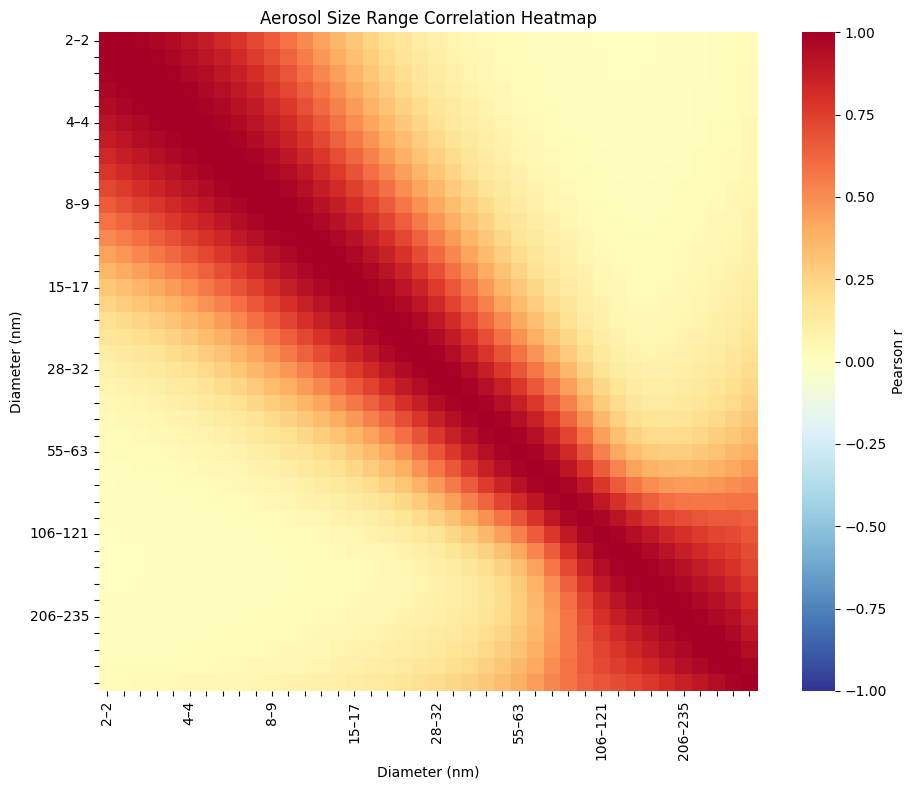

In [34]:
import seaborn as sns
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    Radius = np.logspace(0,np.log10(200),41)    
    Corr_ds = Function.NorERF(ds, Radius)
    n_radii = len(Corr_ds.radius)
    
    # Differential size bins
    data_matrix = np.array([
        (Corr_ds.isel(radius=r) - Corr_ds.isel(radius=r+1)).values.flatten()
        for r in range(n_radii - 1)
    ])
    labels = [f'{Corr_ds.radius.values[r]*2:.0f}–{Corr_ds.radius.values[r+1]*2:.0f}'
              for r in range(n_radii - 1)]
    
    # Remove columns with any nan/inf
    finite_mask = np.isfinite(data_matrix).all(axis=0)
    data_matrix = data_matrix[:, finite_mask]
    
    # Compute correlation matrix
    corr_matrix = np.corrcoef(data_matrix)
    
    # Plot
    fig, ax = plt.subplots(figsize=[10, 8])
    sns.heatmap(
        corr_matrix,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        cmap='RdYlBu_r',
        vmin=-1, vmax=1,
        square=True,
        cbar_kws={'label': 'Pearson r'}
    )
    ax.set_title('Aerosol Size Range Correlation Heatmap')
    ax.set_xlabel('Diameter (nm)')
    ax.set_ylabel('Diameter (nm)')
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 5 != 0:
            label.set_visible(False)
    for i, label in enumerate(ax.get_yticklabels()):
        if i % 5 != 0:
            label.set_visible(False)
    plt.tight_layout()
    plt.show()

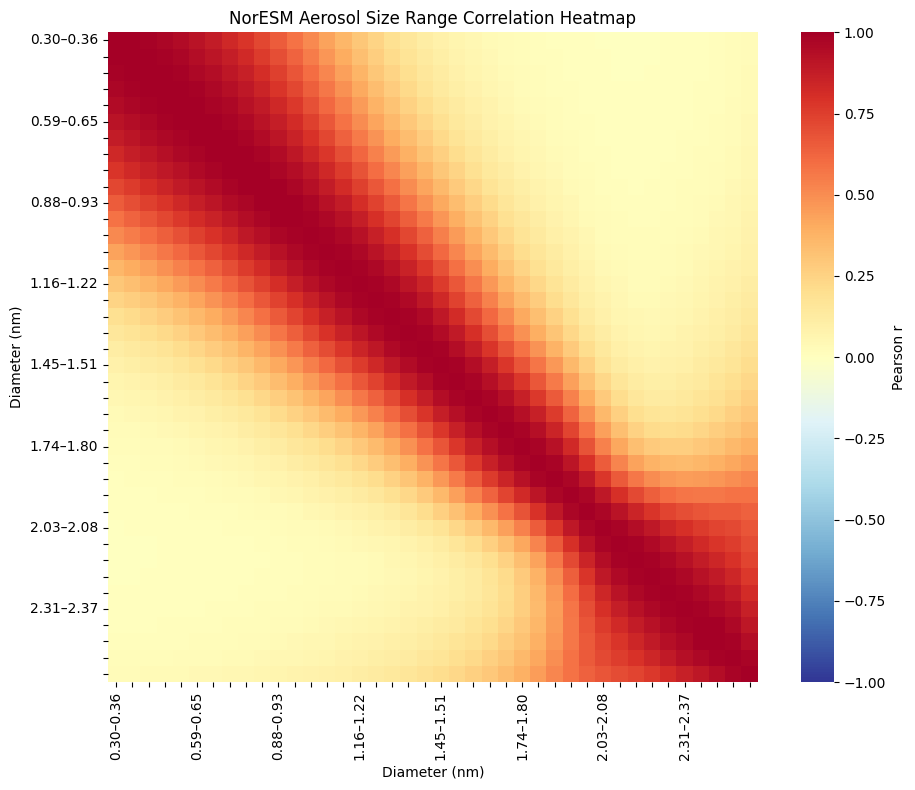

In [41]:
# Plot
labels = [f'{np.log10(Corr_ds.radius.values[r]*2):.2f}–{np.log10(Corr_ds.radius.values[r+1]*2):.2f}'
              for r in range(n_radii - 1)]
fig, ax = plt.subplots(figsize=[10, 8])
sns.heatmap(
    corr_matrix,
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    cmap='RdYlBu_r',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('NorESM Aerosol Size Range Correlation Heatmap')
ax.set_xlabel('Diameter (nm)')
ax.set_ylabel('Diameter (nm)')
# Thin out tick labels to avoid crowding
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)
for i, label in enumerate(ax.get_yticklabels()):
    if i % 5 != 0:
        label.set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
ECds = xr.open_dataset('/share/pech2273/EC_Earth_Data.nc')
ECds = ECds.chunk(time = 1000)
stations = ECds["station"].values
VarList = []
IFSVarList = []
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})
ECds = ECds.sel(time = slice('2012-01-01T03:00:00.000000000','2015-01-01T03:00:00.000000000'))

#reg_ds = xr.open_dataset('/share/pech2273/EC_Earth_Susceptibility_All_Levels.nc')
#CCN_CDNC_ds = xr.open_dataset('/share/pech2273/EC_Earth_Data_CCN_CDNC.nc')
#dNdlogD = xr.open_dataset('/share/pech2273/EC_Earth_PNSD.nc')

In [11]:
#Define variables for the ERF
radius_variables = ['RDRY_NUS', 'RDRY_AIS', 'RDRY_ACS', 'RWET_AII', 'RDRY_COS', 'RWET_ACI', 'RWET_COI']
Numb_variables = ['N_NUS', 'N_AIS', 'N_ACS', 'N_AII', 'N_COS', 'N_ACI', 'N_COI']
ModesSigma = [1.59, 1.59, 1.59, 2.0, 1.59, 1.59, 2.0]

for radius, number in zip(radius_variables, Numb_variables):
    if radius in ECds and number in ECds:
            if ECds[radius].attrs["units"] == "m" :
                ECds[radius] = ECds[radius]*1e9
                ECds[radius].attrs["units"] = "nm"
                print(f' {radius} changed to nm')
            else:
                continue
            if  ECds[number].attrs["units"] == '1 m-3':
                ECds[number] = ECds[number]/1e6
                ECds[number].attrs["units"] = "#cm-3"
                print(f' {number} added to Dataset')
            else: 
                continue
    else:
        print(f'{radius, number} not found in EC Path Data')

 RDRY_NUS changed to nm
 N_NUS added to Dataset
 RDRY_AIS changed to nm
 N_AIS added to Dataset
 RDRY_ACS changed to nm
 N_ACS added to Dataset
 RWET_AII changed to nm
 N_AII added to Dataset
 RDRY_COS changed to nm
 N_COS added to Dataset
 RWET_ACI changed to nm
 N_ACI added to Dataset
 RWET_COI changed to nm
 N_COI added to Dataset


In [37]:
Radius = np.logspace(0,np.log10(200),41)    
ECCorr_ds = Function.ECEarthERF(ECds, Radius)


In [38]:
n_radii = len(ECCorr_ds.radius)

# Differential size bins
ECdata_matrix = np.array([
    (ECCorr_ds.isel(radius=r) - ECCorr_ds.isel(radius=r+1)).values.flatten()
    for r in range(n_radii - 1)
])
labels = [f'{ECCorr_ds.radius.values[r]*2:.0f}–{ECCorr_ds.radius.values[r+1]*2:.0f}'
          for r in range(n_radii - 1)]

# Remove columns with any nan/inf
finite_mask = np.isfinite(ECdata_matrix).all(axis=0)
ECdata_matrix = ECdata_matrix[:, finite_mask]

# Compute correlation matrix
ECcorr_matrix = np.corrcoef(ECdata_matrix)

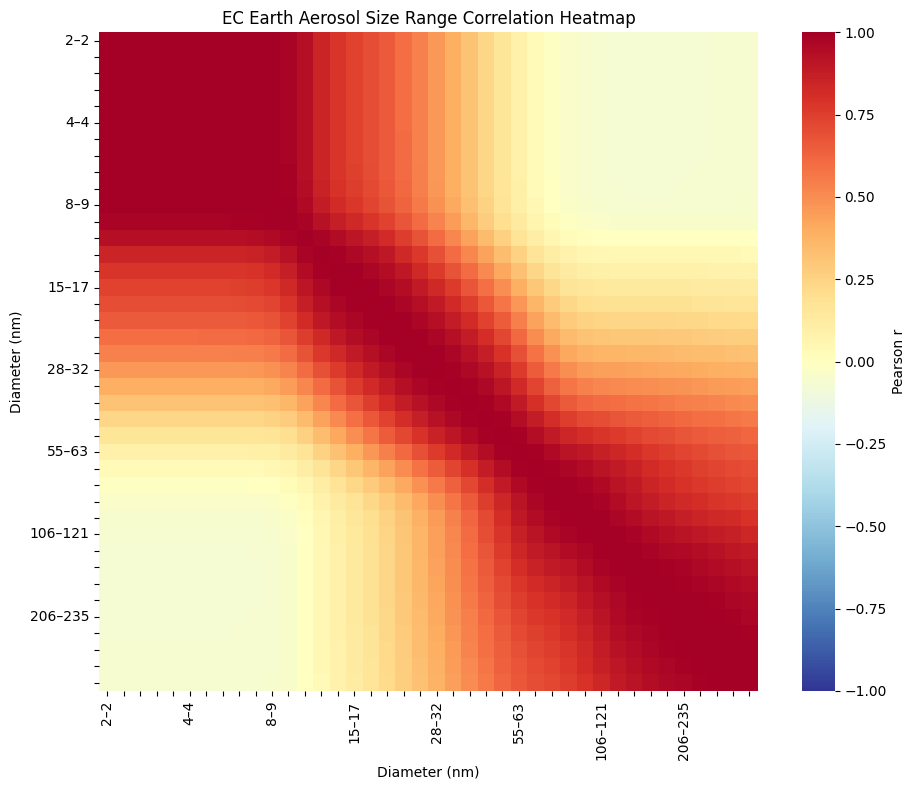

In [39]:
fig, ax = plt.subplots(figsize=[10, 8])
sns.heatmap(
    ECcorr_matrix,
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    cmap='RdYlBu_r',
    vmin=-1, vmax=1,
    square=True,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('EC Earth Aerosol Size Range Correlation Heatmap')
ax.set_xlabel('Diameter (nm)')
ax.set_ylabel('Diameter (nm)')
# Thin out tick labels to avoid crowding
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)
for i, label in enumerate(ax.get_yticklabels()):
    if i % 5 != 0:
        label.set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
ECdata_matrix

In [20]:
Radius = np.linspace(0, 200, 41)
Corr_ds = Function.NorERF(ds, Radius)
n_radii = len(Corr_ds.radius)
stations = Corr_ds.station.values

# Build and save correlation matrices to dataset
corr_matrices = np.full((len(stations), n_radii-1, n_radii-1), np.nan)

for idx, station in enumerate(stations):
    data_matrix = np.array([
        (Corr_ds.sel(station=station).isel(radius=r) - 
         Corr_ds.sel(station=station).isel(radius=r+1)).values.flatten()
        for r in range(n_radii - 1)
    ])
    finite_mask = np.isfinite(data_matrix).all(axis=0)
    data_matrix = data_matrix[:, finite_mask]
    corr_matrices[idx] = np.corrcoef(data_matrix)

bin_labels = [f'{Corr_ds.radius.values[r]*2:.0f}–{Corr_ds.radius.values[r+1]*2:.0f}'
              for r in range(n_radii - 1)]

NorCorrMat_ds = xr.Dataset(
    {"corr": (["station", "bin_x", "bin_y"], corr_matrices)},
    coords={
        "station": stations,
        "bin_x": bin_labels,
        "bin_y": bin_labels,
    }
)
NorCorrMat_ds.to_netcdf('/share/pech2273/NorESMcorr_matrices.nc')

In [26]:
Radius = np.linspace(0, 200, 41)
n_radii = len(ECCorr_ds.radius)
stations = ECCorr_ds.station.values

# Build and save correlation matrices to dataset
ECcorr_matrices = np.full((len(stations), n_radii-1, n_radii-1), np.nan)

for idx, station in enumerate(stations):
    data_matrix = np.array([
        (ECCorr_ds.sel(station=station).isel(radius=r) - 
         ECCorr_ds.sel(station=station).isel(radius=r+1)).values.flatten()
        for r in range(n_radii - 1)
    ])
    finite_mask = np.isfinite(data_matrix).all(axis=0)
    data_matrix = data_matrix[:, finite_mask]
    ECcorr_matrices[idx] = np.corrcoef(data_matrix)

bin_labels = [f'{ECCorr_ds.radius.values[r]*2:.0f}–{ECCorr_ds.radius.values[r+1]*2:.0f}'
              for r in range(n_radii - 1)]

ECCorrMat_ds = xr.Dataset(
    {"corr": (["station", "bin_x", "bin_y"], ECcorr_matrices)},
    coords={
        "station": stations,
        "bin_x": bin_labels,
        "bin_y": bin_labels,
    }
)
ECCorrMat_ds.to_netcdf('/share/pech2273/ECESMcorr_matrices.nc')

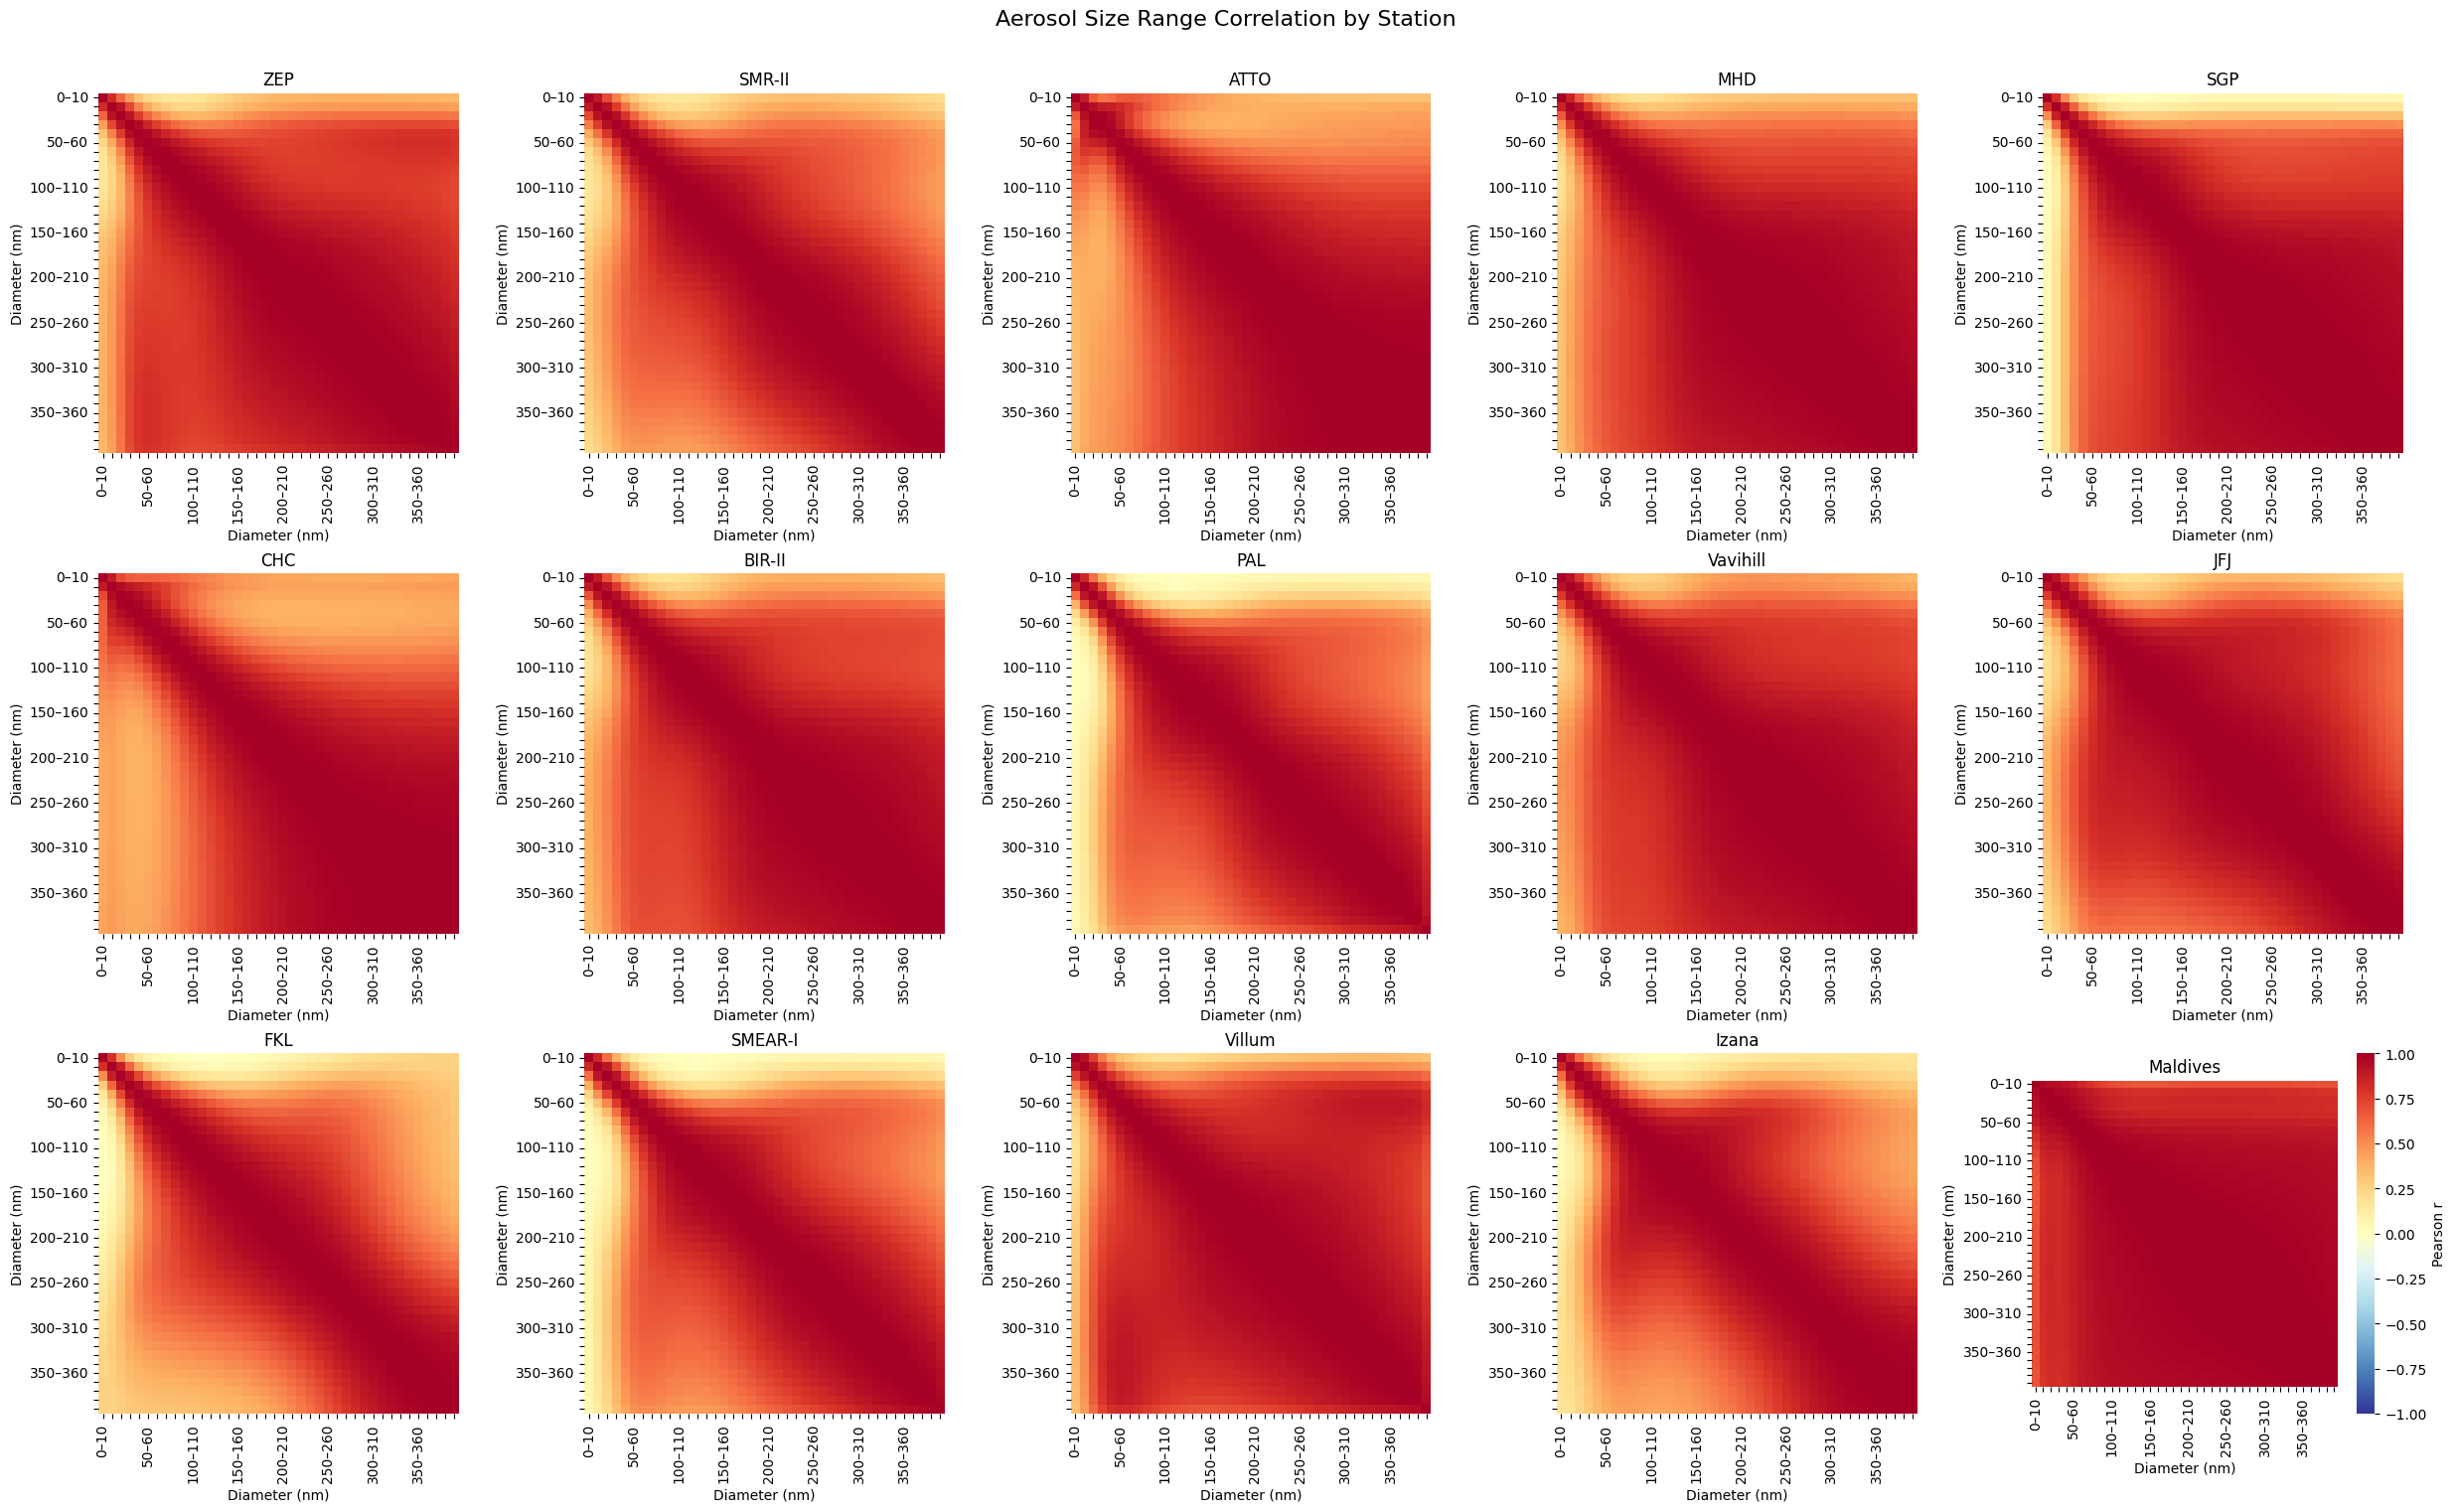

In [22]:
import seaborn as sns

stations = NorCorrMat_ds.station.values
labels = NorCorrMat_ds.bin_x.values

fig, axes = plt.subplots(3, 5, figsize=[25, 15])

for idx, station in enumerate(stations):
    ax = axes[idx // 5, idx % 5]
    corr_matrix = NorCorrMat_ds['corr'].sel(station=station).values

    sns.heatmap(
        corr_matrix,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        cmap='RdYlBu_r',
        vmin=-1, vmax=1,
        square=True,
        cbar=idx == 14,
        cbar_kws={'label': 'Pearson r'}
    )
    ax.set_title(station)
    ax.set_xlabel('Diameter (nm)')
    ax.set_ylabel('Diameter (nm)')
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 5 != 0:
            label.set_visible(False)
    for i, label in enumerate(ax.get_yticklabels()):
        if i % 5 != 0:
            label.set_visible(False)

plt.suptitle('Aerosol Size Range Correlation by Station', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

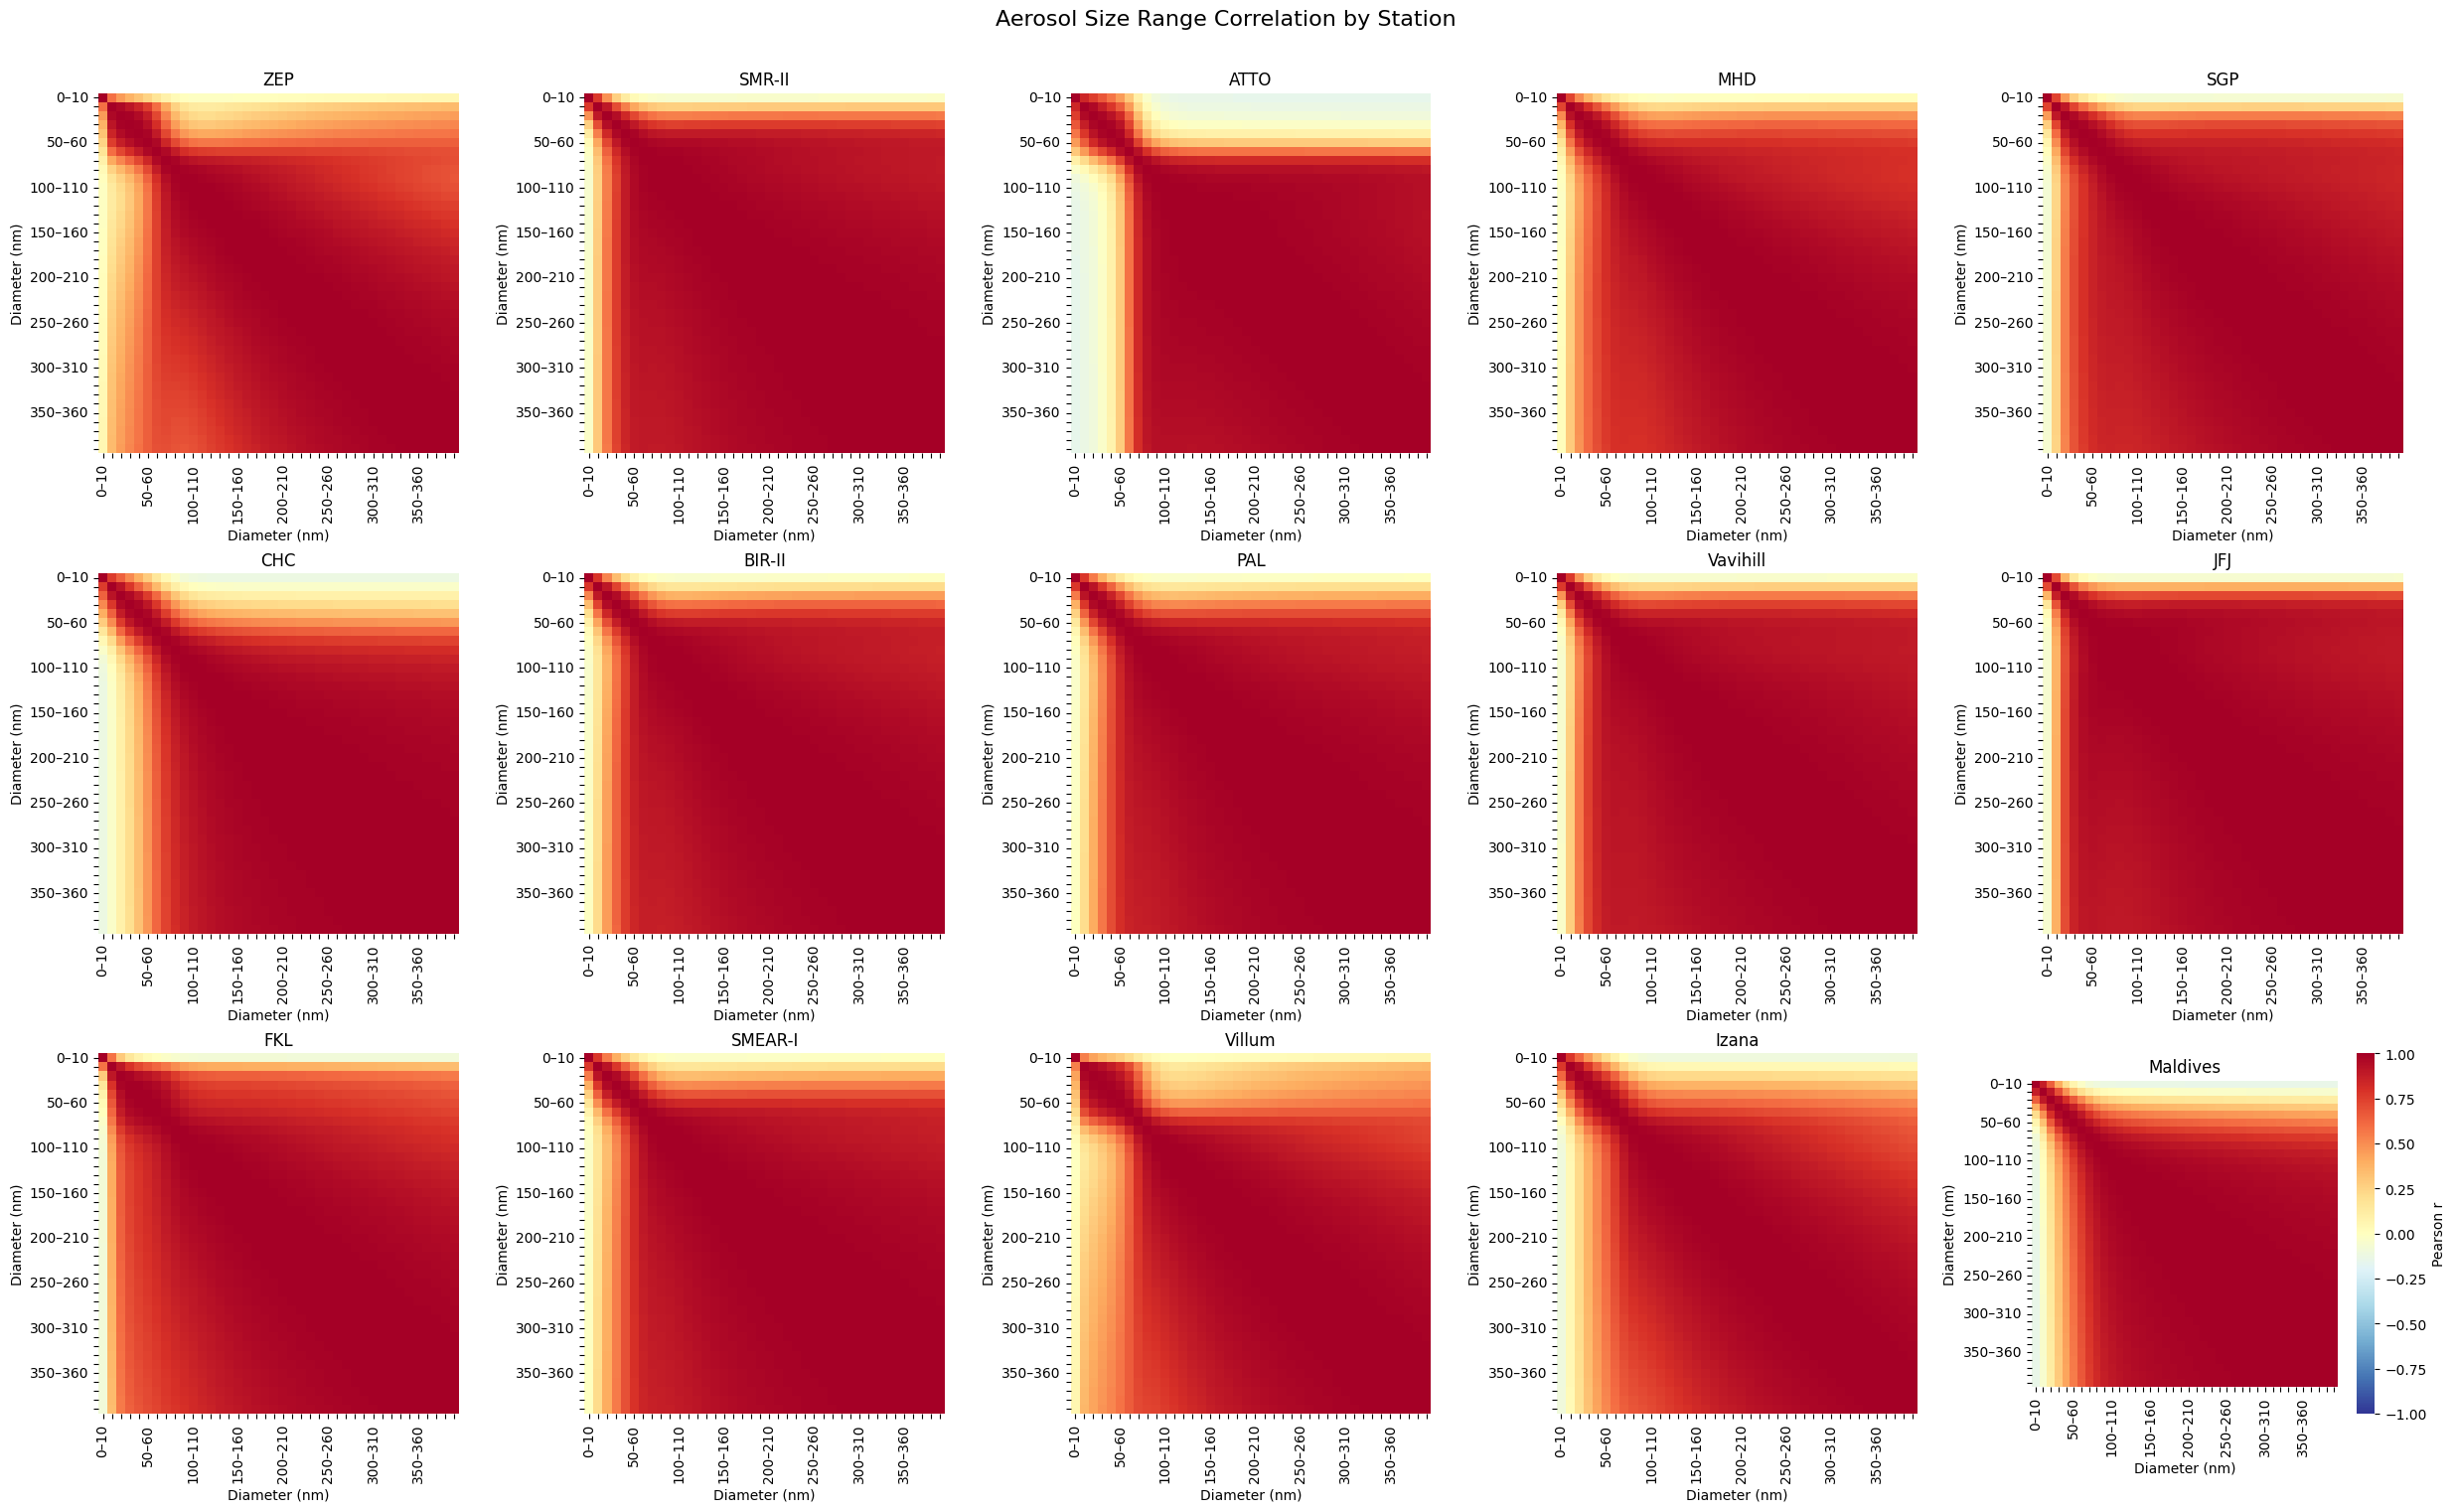

In [27]:
import seaborn as sns

stations = ECCorrMat_ds.station.values
labels = ECCorrMat_ds.bin_x.values

fig, axes = plt.subplots(3, 5, figsize=[25, 15])

for idx, station in enumerate(stations):
    ax = axes[idx // 5, idx % 5]
    corr_matrix = ECCorrMat_ds['corr'].sel(station=station).values

    sns.heatmap(
        corr_matrix,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        cmap='RdYlBu_r',
        vmin=-1, vmax=1,
        square=True,
        cbar=idx == 14,
        cbar_kws={'label': 'Pearson r'}
    )
    ax.set_title(station)
    ax.set_xlabel('Diameter (nm)')
    ax.set_ylabel('Diameter (nm)')
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 5 != 0:
            label.set_visible(False)
    for i, label in enumerate(ax.get_yticklabels()):
        if i % 5 != 0:
            label.set_visible(False)

plt.suptitle('Aerosol Size Range Correlation by Station', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

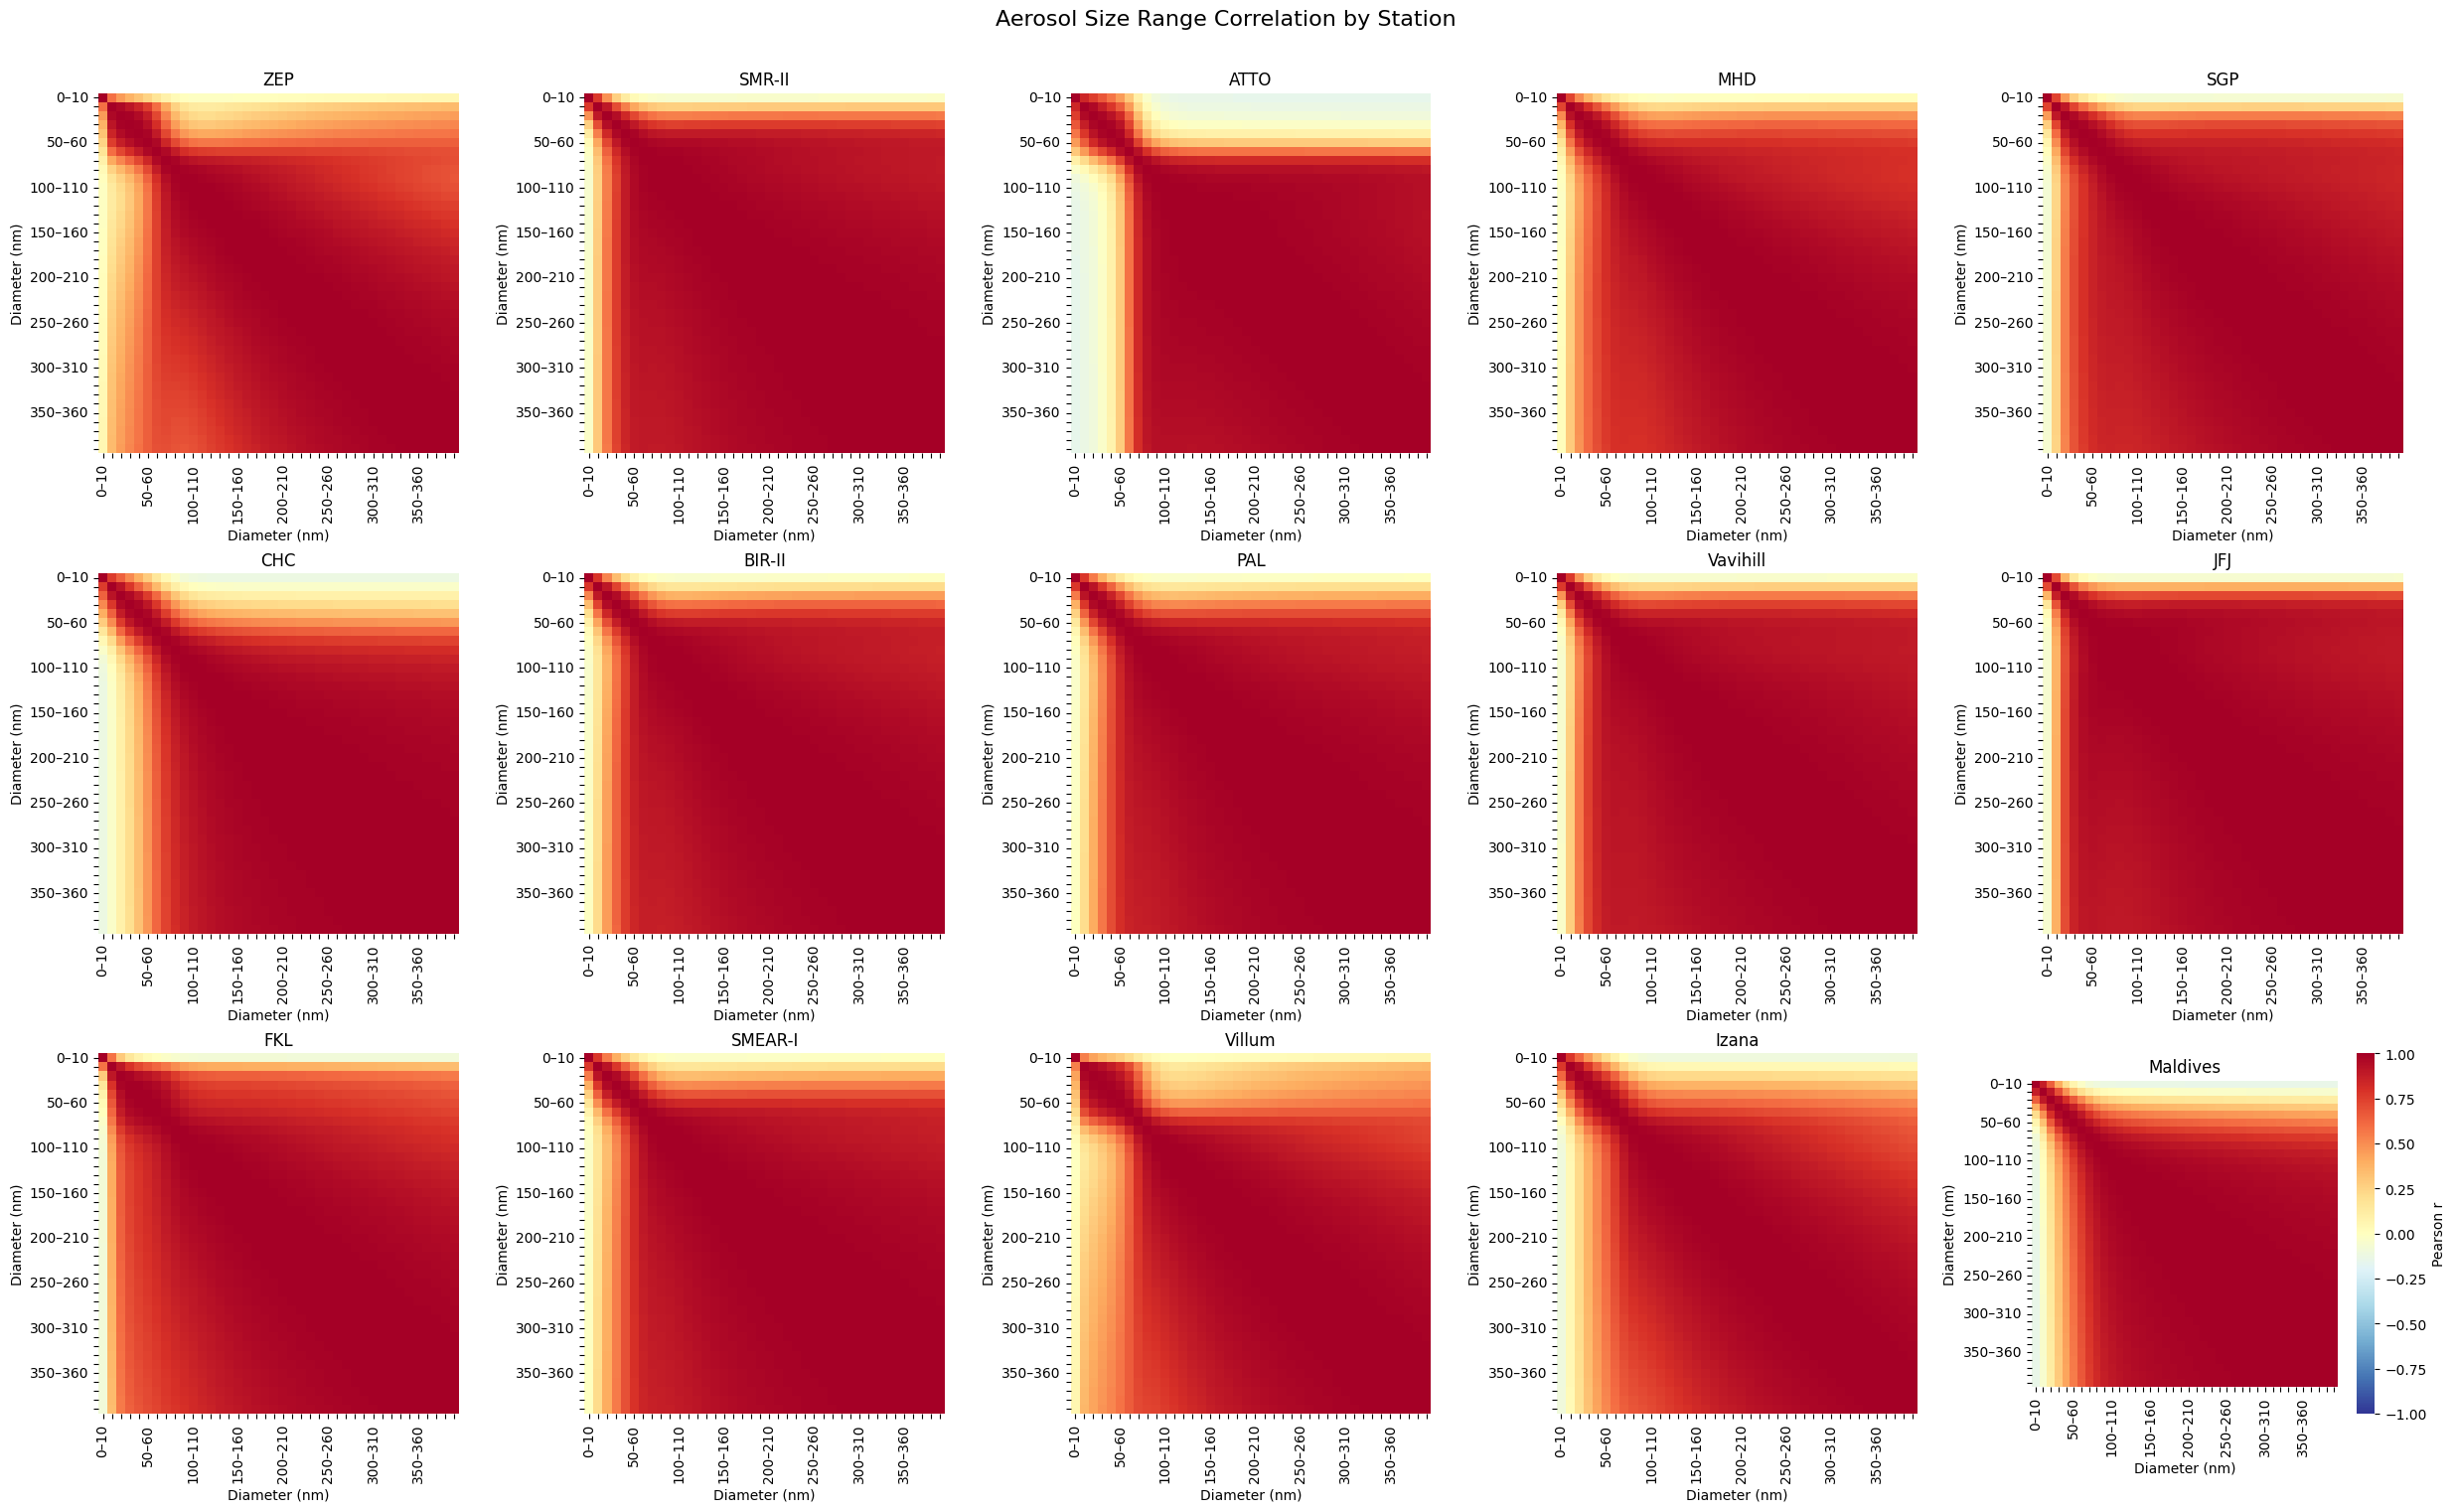

In [19]:
import seaborn as sns


n_radii = len(ECCorr_ds.radius)
stations = ECCorr_ds.station.values

labels = [f'{ECCorr_ds.radius.values[r]*2:.0f}–{ECCorr_ds.radius.values[r+1]*2:.0f}'
          for r in range(n_radii - 1)]

fig, axes = plt.subplots(3, 5, figsize=[25, 15])

for idx, station in enumerate(stations):
    ax = axes[idx // 5, idx % 5]

    ECdata_matrix = np.array([
        (ECCorr_ds.sel(station=station).isel(radius=r) - 
         ECCorr_ds.sel(station=station).isel(radius=r+1)).values.flatten()
        for r in range(n_radii - 1)
    ])

    finite_mask = np.isfinite(ECdata_matrix).all(axis=0)
    ECdata_matrix = ECdata_matrix[:, finite_mask]
    ECcorr_matrix = np.corrcoef(ECdata_matrix)

    sns.heatmap(
        ECcorr_matrix,
        ax=ax,
        xticklabels=labels,
        yticklabels=labels,
        cmap='RdYlBu_r',
        vmin=-1, vmax=1,
        square=True,
        cbar=idx == 14,  # only show colorbar on last plot
        cbar_kws={'label': 'Pearson r'}
    )
    ax.set_title(station)
    ax.set_xlabel('Diameter (nm)')
    ax.set_ylabel('Diameter (nm)')
    for i, label in enumerate(ax.get_xticklabels()):
        if i % 5 != 0:
            label.set_visible(False)
    for i, label in enumerate(ax.get_yticklabels()):
        if i % 5 != 0:
            label.set_visible(False)

plt.suptitle('Aerosol Size Range Correlation by Station', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()